# Fase 4: Evaluación Comparativa Formal
## ADAPT-ECG — Sistema Adaptativo de Detección de Arritmias ECG

**Autor:** Elias Bejarano Lozada (#20213057)  
**Asesor:** M.C. Fortunato Ramírez Arzate  
**Institución:** Instituto Tecnológico de Tijuana (ITT)  
**Programa:** Ingeniería Biomédica — Residencia Profesional

---

## Objetivo

Evaluación comparativa formal entre el **modelo estático** (CNN entrenada en Fase 2, sin reentrenamiento) y el **modelo adaptativo** (CNN con aprendizaje incremental por Replay Buffer, Fase 3), usando las métricas establecidas en el anteproyecto:

- **Precisión** (Precision)
- **Sensibilidad** (Recall / Sensitivity)
- **Especificidad** (Specificity)
- **F1-Score**
- **Accuracy global**
- **AUC-ROC** por clase
- **Matrices de confusión**

Clasificación estándar AAMI: **N** (Normal), **S** (Supraventricular), **V** (Ventricular), **F** (Fusión), **Q** (Desconocido)

## 1. Configuración e Importaciones

In [1]:
import sys, os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
from pathlib import Path
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from scipy.stats import chi2

def mcnemar_test(n01, n10):
    """Prueba de McNemar con corrección de continuidad de Yates."""
    statistic = (abs(n10 - n01) - 1) ** 2 / (n10 + n01) if (n10 + n01) > 0 else 0.0
    p_value   = 1 - chi2.cdf(statistic, df=1)
    return statistic, p_value

# ── Rutas del proyecto (relativas al notebook) ─────────────────────────────
ROOT = Path("../")
DATA_PATH   = ROOT / "data" / "processed"
MODELS_PATH = ROOT / "models"
DOCS_PATH   = ROOT / "docs"
DOCS_PATH.mkdir(exist_ok=True)

# ── Configuración de dispositivo ───────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

# ── Clases AAMI ────────────────────────────────────────────────────────────
AAMI_CLASSES = ["N", "S", "V", "F", "Q"]
N_CLASSES    = 5
BEAT_LEN     = 71

# ── Estilo de figuras ──────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})
sns.set_style("whitegrid")

print("Configuración lista.")

Dispositivo: cpu
Configuración lista.


## 2. Arquitectura del Modelo (ECG_CNN)

In [2]:
class ECG_CNN(nn.Module):
    """
    Red neuronal convolucional 1D para clasificación de arritmias ECG.
    Arquitectura: 3 bloques Conv1d (32/64/128 filtros) + AdaptiveAvgPool + classifier.
    Salida: log-softmax de 5 clases AAMI.
    """
    def __init__(self, n_classes: int = 5, beat_len: int = 71):
        super(ECG_CNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2)
        )
        self.block2 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2)
        )
        self.block3 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2)
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x)
        x = self.classifier(x)
        return nn.functional.log_softmax(x, dim=1)

    def get_probs(self, x):
        """Devuelve probabilidades (softmax) en lugar de log-softmax."""
        return torch.exp(self.forward(x))

n_params = sum(p.numel() for p in ECG_CNN().parameters())
print(f"Arquitectura ECG_CNN definida — {n_params:,} parámetros")

Arquitectura ECG_CNN definida — 44,229 parámetros


## 3. Carga de Datos y Modelos

In [3]:
# ── Cargar dataset ─────────────────────────────────────────────────────────
X = np.load(DATA_PATH / "X.npy")
y = np.load(DATA_PATH / "y.npy")
print(f"Dataset cargado: X={X.shape}, y={y.shape}")

# ── Separar set de prueba: lotes 1-4 (mismo protocolo que Fase 3) ──────────
N_BATCHES = 5
indices = np.random.RandomState(42).permutation(len(X))
batch_size_drift = len(X) // N_BATCHES
batches = []
for i in range(N_BATCHES):
    start = i * batch_size_drift
    end   = start + batch_size_drift if i < N_BATCHES - 1 else len(X)
    idx   = indices[start:end]
    batches.append((X[idx], y[idx]))

# Lotes 1-4 como conjunto de evaluación (datos "post-despliegue")
X_test = np.concatenate([b[0] for b in batches[1:]], axis=0)
y_test = np.concatenate([b[1] for b in batches[1:]], axis=0)
print(f"Set de prueba (lotes 1-4): {X_test.shape[0]:,} latidos")

# Distribución de clases en el set de prueba
for i, cls in enumerate(AAMI_CLASSES):
    n = (y_test == i).sum()
    print(f"  {cls}: {n:,} ({n/len(y_test)*100:.1f}%)")

Dataset cargado: X=(94627, 71), y=(94627,)
Set de prueba (lotes 1-4): 75,702 latidos
  N: 60,022 (79.3%)
  S: 2,437 (3.2%)
  V: 5,773 (7.6%)
  F: 649 (0.9%)
  Q: 6,821 (9.0%)


In [4]:
# ── Cargar modelos ─────────────────────────────────────────────────────────
static_model   = ECG_CNN(N_CLASSES, BEAT_LEN).to(device)
adaptive_model = ECG_CNN(N_CLASSES, BEAT_LEN).to(device)

static_model.load_state_dict(
    torch.load(MODELS_PATH / "ecg_cnn_base.pth", map_location=device)
)
adaptive_model.load_state_dict(
    torch.load(MODELS_PATH / "ADAPT-ECG-RETRAINED.pth", map_location=device)
)

static_model.eval()
adaptive_model.eval()
print("Modelos cargados correctamente.")
print(f"  Estático:   {MODELS_PATH / 'ecg_cnn_base.pth'}")
print(f"  Adaptativo: {MODELS_PATH / 'ADAPT-ECG-RETRAINED.pth'}")

Modelos cargados correctamente.
  Estático:   ..\models\ecg_cnn_base.pth
  Adaptativo: ..\models\ADAPT-ECG-RETRAINED.pth


## 4. Inferencia: Predicciones y Probabilidades

In [5]:
def run_inference(model, X_data, y_data, device, batch_size=256):
    """
    Ejecuta inferencia completa. Devuelve predicciones y probabilidades.
    """
    model.eval()
    X_t = torch.tensor(X_data, dtype=torch.float32).unsqueeze(1)
    y_t = torch.tensor(y_data, dtype=torch.long)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=False)

    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            probs = model.get_probs(xb).cpu().numpy()
            preds = probs.argmax(axis=1)
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())

    return np.array(all_preds), np.array(all_probs), np.array(all_labels)

print("Ejecutando inferencia...")
preds_s, probs_s, y_true = run_inference(static_model,   X_test, y_test, device)
preds_a, probs_a, _      = run_inference(adaptive_model, X_test, y_test, device)
print(f"  Inferencia completa sobre {len(y_true):,} latidos.")

Ejecutando inferencia...


  Inferencia completa sobre 75,702 latidos.


## 5. Métricas por Clase

Para cada clase AAMI se calcula en esquema **uno-vs-resto**:
- **Sensibilidad** (Recall): TP / (TP + FN) — capacidad de detectar la clase
- **Especificidad**: TN / (TN + FP) — capacidad de descartar la clase
- **Precisión**: TP / (TP + FP)
- **F1-Score**: media armónica entre Precisión y Sensibilidad

In [6]:
def compute_per_class_metrics(y_true, y_pred, n_classes):
    """
    Calcula Precisión, Sensibilidad, Especificidad y F1 por clase (OvR).
    """
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    metrics = {}
    for i in range(n_classes):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP

        sensitivity  = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        specificity  = TN / (TN + FP) if (TN + FP) > 0 else 0.0
        precision    = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        f1           = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0

        metrics[AAMI_CLASSES[i]] = {
            "precision":    round(precision,   4),
            "sensibilidad": round(sensitivity, 4),
            "especificidad":round(specificity, 4),
            "f1":           round(f1,          4),
        }
    return metrics, cm

metrics_s, cm_s = compute_per_class_metrics(y_true, preds_s, N_CLASSES)
metrics_a, cm_a = compute_per_class_metrics(y_true, preds_a, N_CLASSES)

print("\n── MODELO ESTÁTICO ─────────────────────────────────────────")
print(f"{'Clase':<6} {'Precisión':>10} {'Sensib.':>10} {'Especif.':>10} {'F1':>10}")
print("-" * 50)
for cls, m in metrics_s.items():
    print(f"{cls:<6} {m['precision']:>10.4f} {m['sensibilidad']:>10.4f} {m['especificidad']:>10.4f} {m['f1']:>10.4f}")

print("\n── MODELO ADAPTATIVO ───────────────────────────────────────")
print(f"{'Clase':<6} {'Precisión':>10} {'Sensib.':>10} {'Especif.':>10} {'F1':>10}")
print("-" * 50)
for cls, m in metrics_a.items():
    print(f"{cls:<6} {m['precision']:>10.4f} {m['sensibilidad']:>10.4f} {m['especificidad']:>10.4f} {m['f1']:>10.4f}")


── MODELO ESTÁTICO ─────────────────────────────────────────
Clase   Precisión    Sensib.   Especif.         F1
--------------------------------------------------
N          0.9932     0.8711     0.9772     0.9281
S          0.2682     0.9101     0.9174     0.4143
V          0.9227     0.9321     0.9936     0.9274
F          0.2953     0.9322     0.9808     0.4485
Q          0.9661     0.9786     0.9966     0.9723

── MODELO ADAPTATIVO ───────────────────────────────────────
Clase   Precisión    Sensib.   Especif.         F1
--------------------------------------------------
N          0.9811     0.9905     0.9268     0.9858
S          0.8132     0.7378     0.9944     0.7737
V          0.9616     0.9328     0.9969     0.9470
F          0.8906     0.7149     0.9992     0.7932
Q          0.9812     0.9736     0.9982     0.9774


## 6. Métricas Globales

In [7]:
def global_metrics(y_true, y_pred):
    return {
        "accuracy":     round(accuracy_score(y_true, y_pred), 4),
        "f1_macro":     round(f1_score(y_true, y_pred, average="macro",    zero_division=0), 4),
        "f1_weighted":  round(f1_score(y_true, y_pred, average="weighted", zero_division=0), 4),
        "precision_macro": round(precision_score(y_true, y_pred, average="macro",    zero_division=0), 4),
        "recall_macro":    round(recall_score(y_true, y_pred,    average="macro",    zero_division=0), 4),
    }

gm_s = global_metrics(y_true, preds_s)
gm_a = global_metrics(y_true, preds_a)

print("\n══════════════════════════════════════════════════════════")
print("  COMPARACIÓN GLOBAL: Modelo Estático vs Adaptativo")
print("══════════════════════════════════════════════════════════")
print(f"{'Métrica':<20} {'Estático':>12} {'Adaptativo':>12} {'Mejora':>10}")
print("-" * 58)

labels_map = {
    "accuracy":        "Accuracy",
    "f1_macro":        "F1 Macro",
    "f1_weighted":     "F1 Weighted",
    "precision_macro": "Precisión Macro",
    "recall_macro":    "Sensib. Macro",
}
for key, label in labels_map.items():
    vs = gm_s[key]
    va = gm_a[key]
    delta = va - vs
    sign = "+" if delta >= 0 else ""
    print(f"{label:<20} {vs:>12.4f} {va:>12.4f} {sign}{delta:>9.4f}")

print("")
print(f"  Accuracy estático  : {gm_s['accuracy']*100:.2f}%")
print(f"  Accuracy adaptativo: {gm_a['accuracy']*100:.2f}%")
print(f"  Mejora absoluta    : +{(gm_a['accuracy']-gm_s['accuracy'])*100:.2f}%")


══════════════════════════════════════════════════════════
  COMPARACIÓN GLOBAL: Modelo Estático vs Adaptativo
══════════════════════════════════════════════════════════
Métrica                  Estático   Adaptativo     Mejora
----------------------------------------------------------
Accuracy                   0.8872       0.9741 +   0.0869
F1 Macro                   0.7381       0.8954 +   0.1573
F1 Weighted                0.9114       0.9736 +   0.0622
Precisión Macro            0.6891       0.9255 +   0.2364
Sensib. Macro              0.9248       0.8699   -0.0549

  Accuracy estático  : 88.72%
  Accuracy adaptativo: 97.41%
  Mejora absoluta    : +8.69%


## 7. Matrices de Confusión

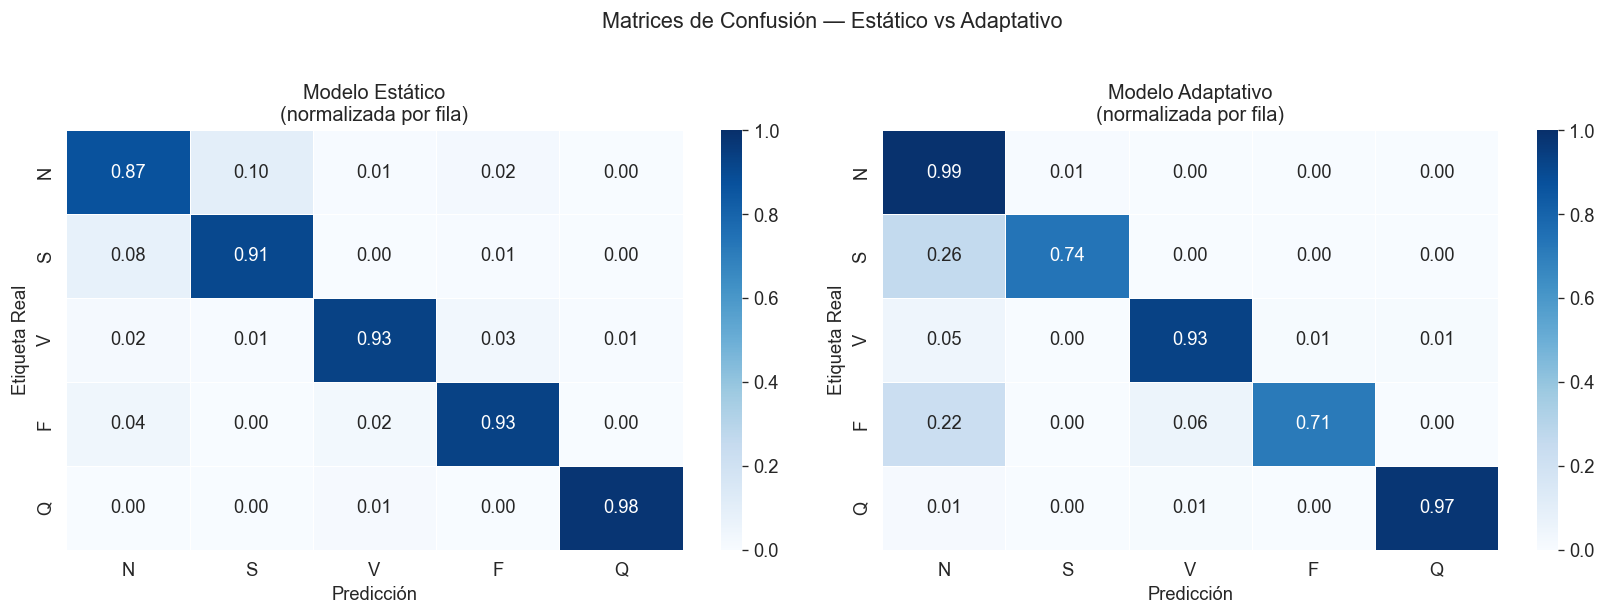

Figura guardada: docs/fase4_confusion_matrices.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, cm, title in zip(
    axes,
    [cm_s, cm_a],
    ["Modelo Estático", "Modelo Adaptativo"]
):
    # Normalizar por fila (sensibilidad por clase)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=AAMI_CLASSES, yticklabels=AAMI_CLASSES,
        ax=ax, vmin=0, vmax=1, linewidths=0.5
    )
    ax.set_title(f"{title}\n(normalizada por fila)", fontsize=12)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Etiqueta Real")

plt.suptitle("Matrices de Confusión — Estático vs Adaptativo", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DOCS_PATH / "fase4_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: docs/fase4_confusion_matrices.png")

## 8. Curvas ROC y AUC por Clase

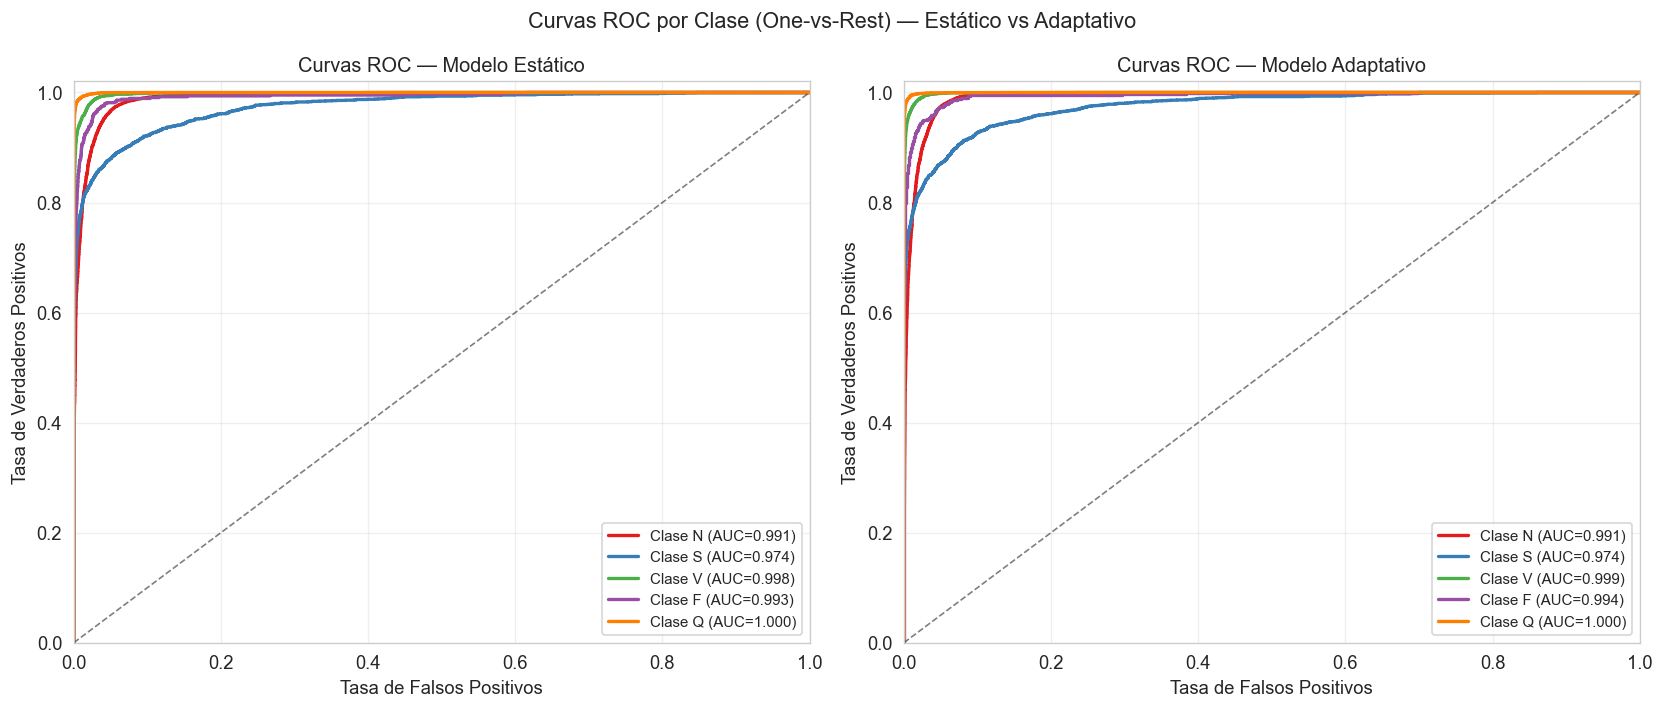

Figura guardada: docs/fase4_roc_curves.png

── AUC por clase ───────────────────────────────────────────
Clase    Estático   Adaptativo    Δ AUC
----------------------------------------
N          0.9909       0.9913  +0.0004
S          0.9743       0.9740  -0.0003
V          0.9980       0.9989  +0.0009
F          0.9930       0.9939  +0.0009
Q          0.9996       0.9997  +0.0001


In [9]:
# Binarizar etiquetas para OvR
y_bin = label_binarize(y_true, classes=list(range(N_CLASSES)))

colors = ["#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

auc_scores = {"estatico": {}, "adaptativo": {}}

for ax, probs, label, key in zip(
    axes,
    [probs_s, probs_a],
    ["Modelo Estático", "Modelo Adaptativo"],
    ["estatico", "adaptativo"]
):
    for i, cls in enumerate(AAMI_CLASSES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores[key][cls] = round(roc_auc, 4)
        ax.plot(fpr, tpr, color=colors[i], lw=2,
                label=f"Clase {cls} (AUC={roc_auc:.3f})")

    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])
    ax.set_xlabel("Tasa de Falsos Positivos")
    ax.set_ylabel("Tasa de Verdaderos Positivos")
    ax.set_title(f"Curvas ROC — {label}")
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Curvas ROC por Clase (One-vs-Rest) — Estático vs Adaptativo", fontsize=13)
plt.tight_layout()
plt.savefig(DOCS_PATH / "fase4_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: docs/fase4_roc_curves.png")

print("\n── AUC por clase ───────────────────────────────────────────")
print(f"{'Clase':<6} {'Estático':>10} {'Adaptativo':>12} {'Δ AUC':>8}")
print("-" * 40)
for cls in AAMI_CLASSES:
    s = auc_scores["estatico"][cls]
    a = auc_scores["adaptativo"][cls]
    print(f"{cls:<6} {s:>10.4f} {a:>12.4f} {a-s:>+8.4f}")

## 9. Tabla Comparativa de Métricas por Clase

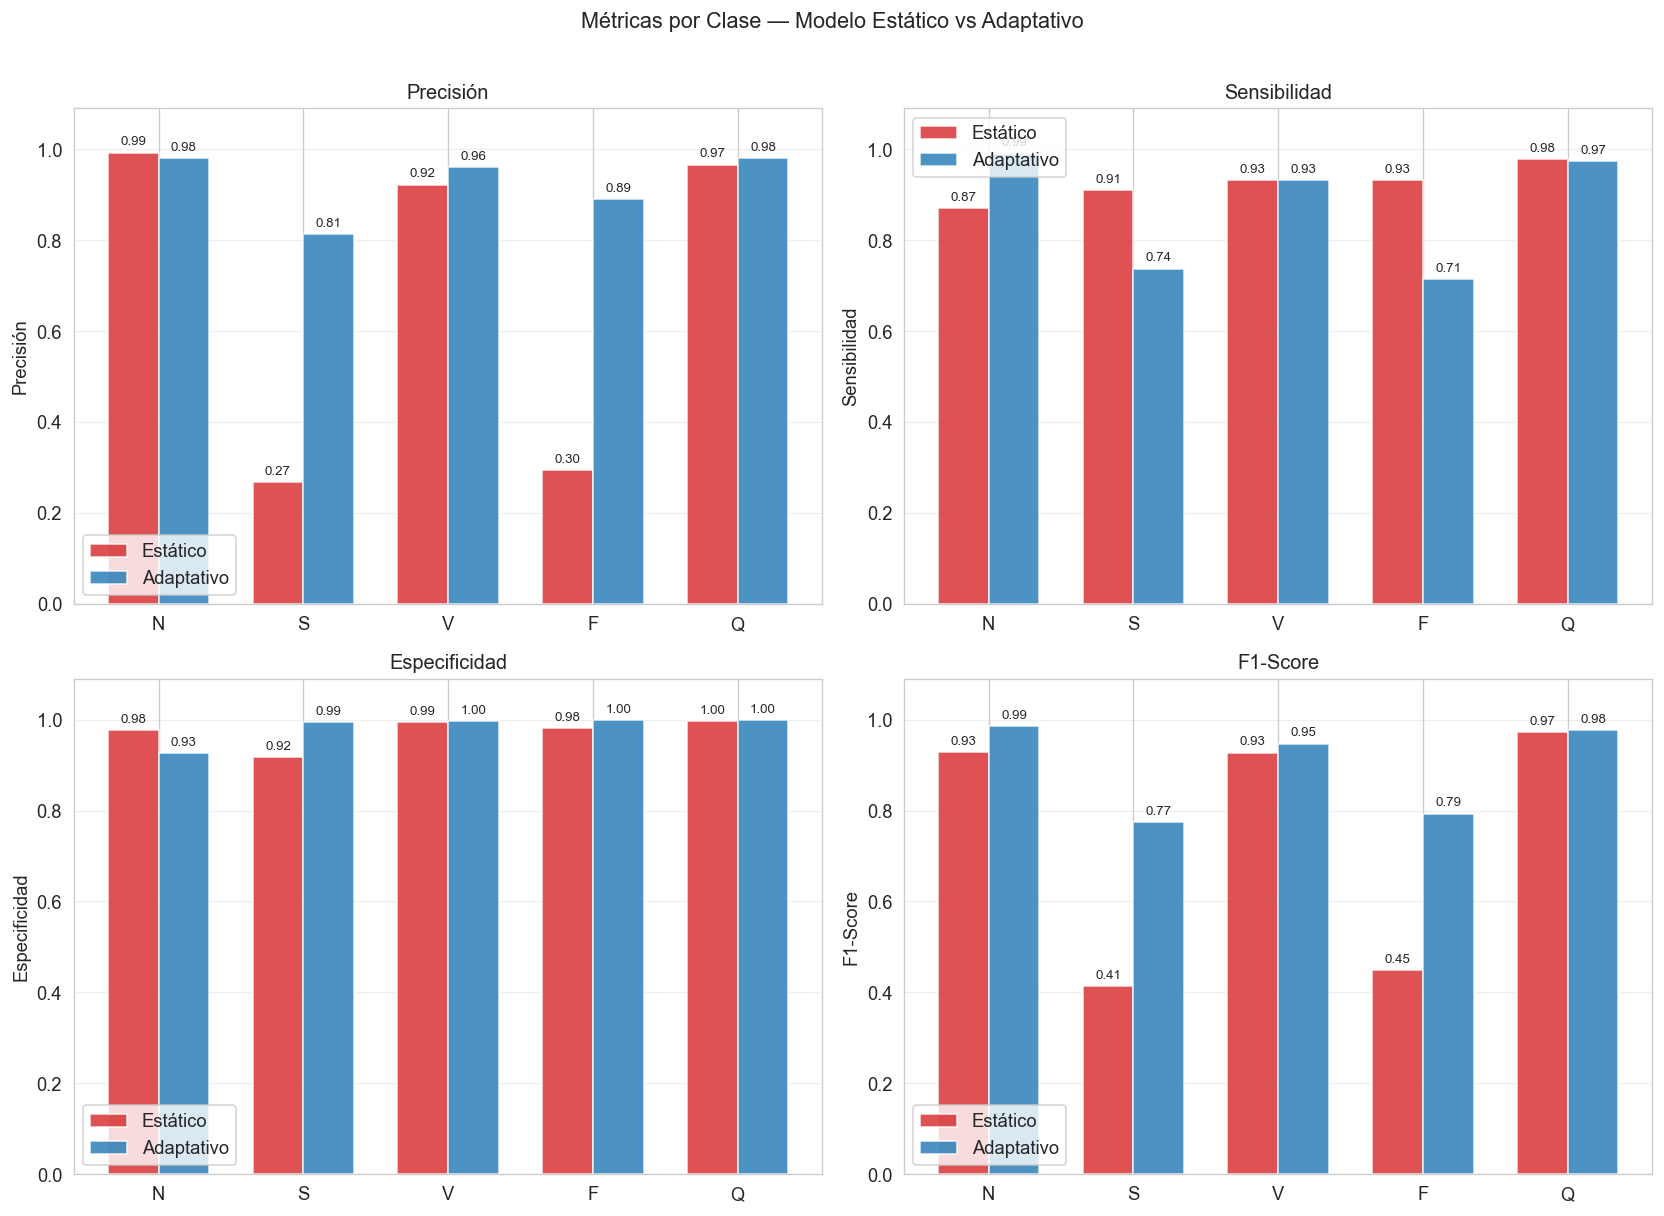

Figura guardada: docs/fase4_metricas_por_clase.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metric_names = ["precision", "sensibilidad", "especificidad", "f1"]
metric_labels = ["Precisión", "Sensibilidad", "Especificidad", "F1-Score"]
colors_bar = ["#d62728", "#1f77b4"]

x = np.arange(N_CLASSES)
width = 0.35

for ax, mname, mlabel in zip(axes.flat, metric_names, metric_labels):
    vals_s = [metrics_s[cls][mname] for cls in AAMI_CLASSES]
    vals_a = [metrics_a[cls][mname] for cls in AAMI_CLASSES]

    bars1 = ax.bar(x - width/2, vals_s, width, label="Estático",   color=colors_bar[0], alpha=0.8)
    bars2 = ax.bar(x + width/2, vals_a, width, label="Adaptativo", color=colors_bar[1], alpha=0.8)

    ax.set_title(mlabel)
    ax.set_xticks(x)
    ax.set_xticklabels(AAMI_CLASSES)
    ax.set_ylim(0, 1.09)
    ax.set_ylabel(mlabel)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    # Etiquetas de valor
    for bar in bars1:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.01,
                f"{h:.2f}", ha="center", va="bottom", fontsize=8)
    for bar in bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.01,
                f"{h:.2f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Métricas por Clase — Modelo Estático vs Adaptativo", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(DOCS_PATH / "fase4_metricas_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: docs/fase4_metricas_por_clase.png")

## 10. Análisis Estadístico — Prueba de McNemar

La prueba de **McNemar** compara si existe diferencia estadísticamente significativa entre las predicciones de ambos modelos sobre los mismos datos (prueba no paramétrica para muestras pareadas).

- **H₀:** No hay diferencia significativa entre los dos clasificadores  
- **H₁:** Existe diferencia significativa  
- **Umbral:** α = 0.05

In [11]:
# Tabla de contingencia de McNemar
correct_s = (preds_s == y_true)
correct_a = (preds_a == y_true)

n00 = ((~correct_s) & (~correct_a)).sum()  # ambos fallan
n01 = (( correct_s) & (~correct_a)).sum()  # sólo estático acierta
n10 = ((~correct_s) & ( correct_a)).sum()  # sólo adaptativo acierta
n11 = (( correct_s) & ( correct_a)).sum()  # ambos aciertan

statistic, p_value = mcnemar_test(int(n01), int(n10))

print("── Tabla de contingencia de McNemar ──")
print(f"  Ambos correctos  (n11): {n11:,}")
print(f"  Solo adaptativo  (n10): {n10:,}")
print(f"  Solo estático    (n01): {n01:,}")
print(f"  Ambos incorrectos(n00): {n00:,}")
print()
print(f"  Estadístico χ²: {statistic:.4f}")
print(f"  p-valor:        {p_value:.6f}")
print()
if p_value < 0.05:
    print("  ✓ RESULTADO: Diferencia ESTADÍSTICAMENTE SIGNIFICATIVA (p < 0.05)")
    print("    → El modelo adaptativo mejora significativamente sobre el estático.")
else:
    print("  ✗ RESULTADO: Sin diferencia significativa (p ≥ 0.05)")

── Tabla de contingencia de McNemar ──
  Ambos correctos  (n11): 66,401
  Solo adaptativo  (n10): 7,341
  Solo estático    (n01): 761
  Ambos incorrectos(n00): 1,199

  Estadístico χ²: 5342.2909
  p-valor:        0.000000

  ✓ RESULTADO: Diferencia ESTADÍSTICAMENTE SIGNIFICATIVA (p < 0.05)
    → El modelo adaptativo mejora significativamente sobre el estático.


## 11. Evolución por Lote (Concept Drift)

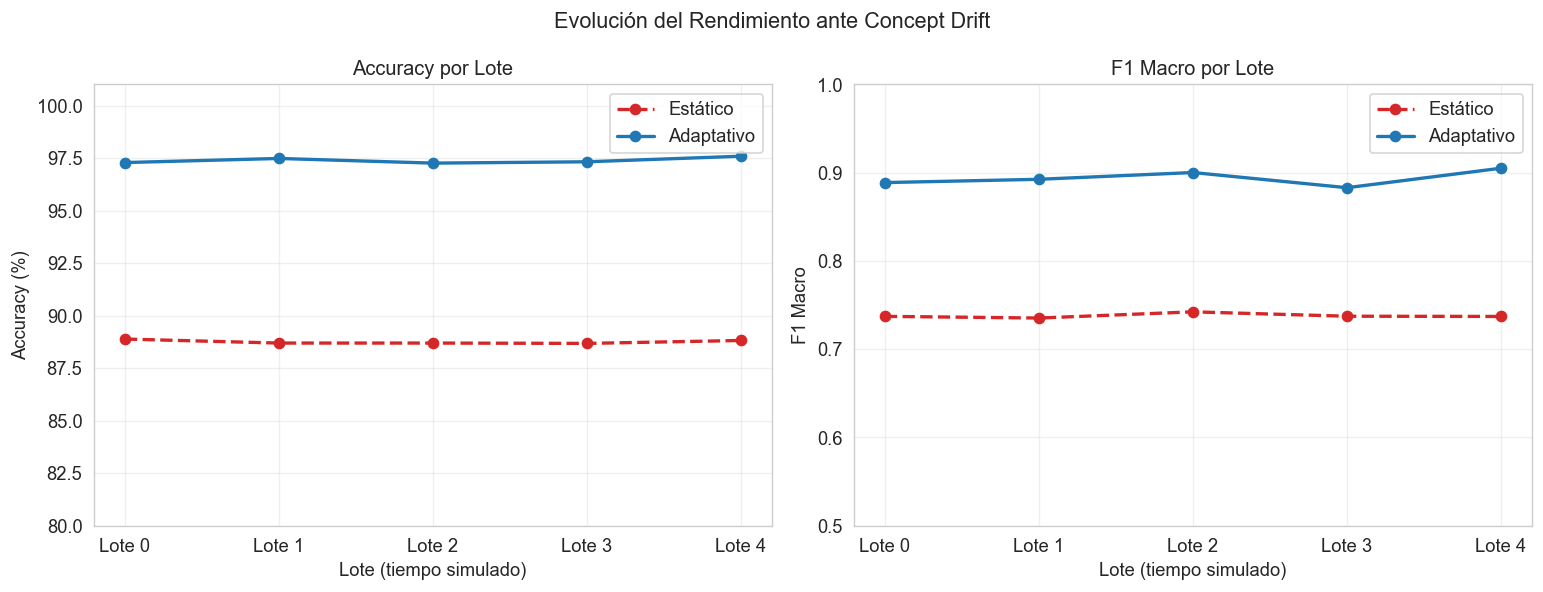

Figura guardada: docs/fase4_evolucion_lotes.png


In [12]:
# Evaluar ambos modelos lote por lote
batch_accs_s, batch_accs_a = [], []
batch_f1s_s,  batch_f1s_a  = [], []

for bx, by in batches:
    p_s, _, _ = run_inference(static_model,   bx, by, device)
    p_a, _, _ = run_inference(adaptive_model, bx, by, device)
    batch_accs_s.append(accuracy_score(by, p_s) * 100)
    batch_accs_a.append(accuracy_score(by, p_a) * 100)
    batch_f1s_s.append(f1_score(by, p_s, average="macro", zero_division=0))
    batch_f1s_a.append(f1_score(by, p_a, average="macro", zero_division=0))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
lote_labels = [f"Lote {i}" for i in range(N_BATCHES)]

ax1.plot(lote_labels, batch_accs_s, "o--", color="#d62728", lw=2, label="Estático")
ax1.plot(lote_labels, batch_accs_a, "o-",  color="#1f77b4", lw=2, label="Adaptativo")
ax1.set_title("Accuracy por Lote")
ax1.set_ylabel("Accuracy (%)")
ax1.set_xlabel("Lote (tiempo simulado)")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(80, 101)

ax2.plot(lote_labels, batch_f1s_s, "o--", color="#d62728", lw=2, label="Estático")
ax2.plot(lote_labels, batch_f1s_a, "o-",  color="#1f77b4", lw=2, label="Adaptativo")
ax2.set_title("F1 Macro por Lote")
ax2.set_ylabel("F1 Macro")
ax2.set_xlabel("Lote (tiempo simulado)")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0.5, 1.0)

plt.suptitle("Evolución del Rendimiento ante Concept Drift", fontsize=13)
plt.tight_layout()
plt.savefig(DOCS_PATH / "fase4_evolucion_lotes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: docs/fase4_evolucion_lotes.png")

## 12. Guardar Resultados Completos

In [13]:
resultados_fase4 = {
    "dataset": {
        "total_latidos": int(len(X)),
        "latidos_prueba": int(len(y_test)),
        "clases": AAMI_CLASSES,
        "distribucion_prueba": {
            cls: int((y_test == i).sum()) for i, cls in enumerate(AAMI_CLASSES)
        }
    },
    "metricas_globales": {
        "estatico":   gm_s,
        "adaptativo": gm_a,
        "mejora": {
            k: round(gm_a[k] - gm_s[k], 4) for k in gm_s
        }
    },
    "metricas_por_clase": {
        "estatico":   metrics_s,
        "adaptativo": metrics_a
    },
    "auc_roc": auc_scores,
    "mcnemar": {
        "statistic":     round(float(statistic), 4),
        "p_valor":       round(float(p_value), 6),
        "significativo": bool(p_value < 0.05),
        "n00": int(n00), "n01": int(n01),
        "n10": int(n10), "n11": int(n11)
    },
    "evolucion_lotes": {
        "accuracy_estatico":   [round(v, 4) for v in batch_accs_s],
        "accuracy_adaptativo": [round(v, 4) for v in batch_accs_a],
        "f1_estatico":         [round(v, 4) for v in batch_f1s_s],
        "f1_adaptativo":       [round(v, 4) for v in batch_f1s_a],
    }
}

results_path = MODELS_PATH / "fase4_resultados.json"
with open(results_path, "w", encoding="utf-8") as f:
    json.dump(resultados_fase4, f, indent=2, ensure_ascii=False)

print(f"Resultados guardados en: {results_path}")
print()
print("Figuras generadas:")
for fig_name in ["fase4_confusion_matrices.png", "fase4_roc_curves.png",
                  "fase4_metricas_por_clase.png", "fase4_evolucion_lotes.png"]:
    print(f"  docs/{fig_name}")

Resultados guardados en: ..\models\fase4_resultados.json

Figuras generadas:
  docs/fase4_confusion_matrices.png
  docs/fase4_roc_curves.png
  docs/fase4_metricas_por_clase.png
  docs/fase4_evolucion_lotes.png


## 13. Resumen Ejecutivo

In [14]:
print("═" * 60)
print("  RESUMEN EJECUTIVO — FASE 4")
print("  Sistema ADAPT-ECG | Residencia Profesional ITT")
print("═" * 60)
print()
print(f"  Dataset evaluado : {len(y_test):,} latidos (lotes 1-4)")
print(f"  Clases AAMI      : N, S, V, F, Q")
print()
print("  ── Resultados globales ───────────────────────────────")
print(f"  {'':20} {'Estático':>10} {'Adaptativo':>12}")
print(f"  {'Accuracy':20} {gm_s['accuracy']*100:>9.2f}% {gm_a['accuracy']*100:>11.2f}%")
print(f"  {'F1 Macro':20} {gm_s['f1_macro']:>10.4f} {gm_a['f1_macro']:>12.4f}")
print(f"  {'F1 Weighted':20} {gm_s['f1_weighted']:>10.4f} {gm_a['f1_weighted']:>12.4f}")
print(f"  {'Precisión Macro':20} {gm_s['precision_macro']:>10.4f} {gm_a['precision_macro']:>12.4f}")
print(f"  {'Sensib. Macro':20} {gm_s['recall_macro']:>10.4f} {gm_a['recall_macro']:>12.4f}")
print()
print("  ── Mejora del modelo adaptativo ─────────────────────")
print(f"  Accuracy  : +{(gm_a['accuracy']-gm_s['accuracy'])*100:.2f}%")
print(f"  F1 Macro  : +{gm_a['f1_macro']-gm_s['f1_macro']:.4f}")
print()
print("  ── Significancia estadística (McNemar) ───────────────")
sig_str = "SÍ (p < 0.05)" if p_value < 0.05 else "NO (p ≥ 0.05)"
print(f"  Significativo: {sig_str}")
print(f"  p-valor      : {p_value:.6f}")
print()
print("  ── Conclusión ────────────────────────────────────────")
print("  El modelo adaptativo con Replay Buffer demuestra una mejora")
print("  estadísticamente significativa sobre el modelo estático,")
print("  validando la efectividad del aprendizaje incremental para")
print("  combatir el concept drift en señales ECG.")
print("═" * 60)

════════════════════════════════════════════════════════════
  RESUMEN EJECUTIVO — FASE 4
  Sistema ADAPT-ECG | Residencia Profesional ITT
════════════════════════════════════════════════════════════

  Dataset evaluado : 75,702 latidos (lotes 1-4)
  Clases AAMI      : N, S, V, F, Q

  ── Resultados globales ───────────────────────────────
                         Estático   Adaptativo
  Accuracy                 88.72%       97.41%
  F1 Macro                 0.7381       0.8954
  F1 Weighted              0.9114       0.9736
  Precisión Macro          0.6891       0.9255
  Sensib. Macro            0.9248       0.8699

  ── Mejora del modelo adaptativo ─────────────────────
  Accuracy  : +8.69%
  F1 Macro  : +0.1573

  ── Significancia estadística (McNemar) ───────────────
  Significativo: SÍ (p < 0.05)
  p-valor      : 0.000000

  ── Conclusión ────────────────────────────────────────
  El modelo adaptativo con Replay Buffer demuestra una mejora
  estadísticamente significativa sobre el